# Part 2B: Real-World Video Engineering (Improved)

In this lab, we move beyond basic scripts and into **Industry-Standard Engineering**. When building Computer Vision applications, the bottleneck isn't just the AI model—it's how Python handles the CPU.

### The Mental Model: From Kitchen to Factory
*   **Sequential**: One chef, one stove. Preps one ingredient, cooks it, then preps the next. (**Blocking**)
*   **Async/Threaded**: One chef, multiple timers. Preps an ingredient, puts it in the oven, and preps the next while the timer runs. (**Concurrency**)
*   **Multiprocessing**: Multiple chefs, multiple kitchens. Everyone works on their own dish simultaneously. (**Parallelism**)

## 1. Setup & The CPU-Bound Reality
We will change `heavy_inference` to be **CPU-intensive** (math calculations) instead of just `time.sleep`. This exposes the weakness of Threads and Async for AI models, which are "CPU-bound."

In [1]:
import time
import asyncio
import matplotlib.pyplot as plt
from threading import Thread
from queue import Queue
from multiprocessing import Process, Queue as MPQueue

## 2. Approach 1: Sequential (The Baseline)

In [2]:
def heavy_inference_seq(frame):
    count = 0
    for i in range(10**5): 
        count += i
    return frame

def run_sequential(frames_to_process=30):
    start_time = time.time()
    for i in range(frames_to_process):
        time.sleep(0.03) # Camera intake
        heavy_inference_seq(None)
    duration = time.time() - start_time
    print(f"Sequential Total Time: {duration:.2f}s")
    return duration

seq_time = run_sequential()

Sequential Total Time: 1.09s


## 3. Approach 2: Threading (The I/O Solution)
Good for waiting on cameras, but still limited by the Global Interpreter Lock (GIL).

In [3]:
class ThreadedProcessor:
    def __init__(self, frames_to_process):
        self.q = Queue(maxsize=1)
        self.frames_to_process = frames_to_process
        
    def producer(self):
        for _ in range(self.frames_to_process):
            time.sleep(0.03)
            if self.q.full():
                try: self.q.get_nowait()
                except: pass
            self.q.put(True)
        self.q.put(None)
            
    def run(self):
        start_time = time.time()
        t = Thread(target=self.producer)
        t.start()
        while True:
            frame = self.q.get()
            if frame is None: break
            heavy_inference_seq(frame)
        t.join()
        duration = time.time() - start_time
        print(f"Threaded Total Time: {duration:.2f}s")
        return duration

thread_time = ThreadedProcessor(30).run()

Threaded Total Time: 0.92s


## 4. Approach 3: Async as a "Stream"
Using an `asyncio.Queue` to simulate a real-time stream. Great for web-connected cameras.

In [4]:
async def async_stream_processor(frames_to_process=30):
    queue = asyncio.Queue(maxsize=1)
    
    async def producer():
        for i in range(frames_to_process):
            await asyncio.sleep(0.03) # 30 FPS arrival
            if queue.full(): await queue.get()
            await queue.put(i)
        await queue.put(None)

    async def consumer():
        while True:
            frame = await queue.get()
            if frame is None: break
            # Simulated async processing
            await asyncio.sleep(0.05) 
            
    start = time.time()
    await asyncio.gather(producer(), consumer())
    duration = time.time() - start
    print(f"Async (Stream) Total Time: {duration:.2f}s")
    return duration

async_time = await async_stream_processor()

Async (Stream) Total Time: 1.10s


## 5. The Industry Standard: Notebook-Safe Multiprocessing

Running `multiprocessing` inside a Jupyter Notebook is notoriously tricky because of how Notebooks handle the "Main" module. On Windows and macOS, the notebook can't easily "export" your functions to the new worker processes.

### Step 1: Create the Engine File
We use the `%%writefile` trick to create a helper file on the hard drive so the worker process has a physical file to read from.

In [5]:
%%writefile engine.py
import time

def heavy_inference(frame):
    """Simulates real CPU load."""
    count = 0
    for i in range(10**5):
        count += i
    return frame

def mp_worker(in_q, out_q):
    """The worker function that lives in the separate process."""
    while True:
        frame = in_q.get()
        if frame is None: 
            break
        result = heavy_inference(frame)
        out_q.put(result)

Writing engine.py


### Step 2: The Notebook Runner
Now, import that file and run the logic. This avoids deadlocks by using an integrated loop to feed the worker while actively draining results.

In [6]:
import engine  # Import the file we just created
from multiprocessing import Process, Queue as MPQueue

def run_multiprocessing_notebook(frames_to_process=30):
    in_q = MPQueue(maxsize=1)
    out_q = MPQueue()
    
    # Start the worker process
    worker = Process(target=engine.mp_worker, args=(in_q, out_q))
    worker.start()
    
    start_time = time.time()
    sent_count = 0
    processed_count = 0

    print(f"Processing {frames_to_process} frames via Multiprocessing...")

    while processed_count < frames_to_process:
        # 1. Feed the worker (Producer)
        if sent_count < frames_to_process:
            if not in_q.full():
                in_q.put(True)
                sent_count += 1
        elif sent_count == frames_to_process:
            in_q.put(None) # Signal worker to stop
            sent_count += 1 # Ensure we only send None once

        # 2. Drain the results (Consumer)
        while not out_q.empty():
            out_q.get_nowait()
            processed_count += 1
            
        time.sleep(0.01) # Small nap to prevent 100% CPU usage on this loop

    worker.join()
    duration = time.time() - start_time
    print(f"Success! Total Time: {duration:.2f}s | FPS: {frames_to_process/duration:.1f}")
    return duration

mp_time = run_multiprocessing_notebook()

Processing 30 frames via Multiprocessing...
Success! Total Time: 0.43s | FPS: 70.4


### Why this version works:
1.  **The Import Fix**: By importing `engine`, the worker process knows exactly where to find `mp_worker`.
2.  **Integrated Loop**: Instead of joining immediately, we loop until all frames are processed.
3.  **Active Draining**: Constantly checking `out_q.empty()` prevents the internal pipe from getting backed up.

**Pro-Tip**: If you change `engine.py`, you must **Restart the Kernel** or use `importlib.reload(engine)` to see the changes.

## 6. Final Comparison & Analysis

| Method | Best For | Why? |
| :--- | :--- | :--- |
| **Sequential** | Simple scripts | Easy to debug, but slow. |
| **Threads** | Web APIs / DB | Good for "waiting" for a response. |
| **AsyncIO** | 1000s of connections | Lowest overhead for massive I/O. |
| **Multiprocessing** | **AI Inference** | The only way to use 100% of your CPU/GPU cores. |

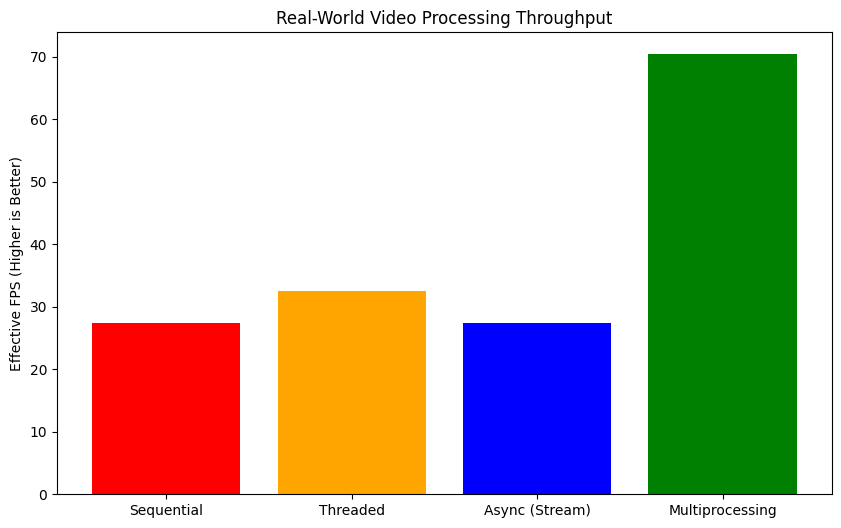

In [7]:
results = {
    "Sequential": seq_time,
    "Threaded": thread_time,
    "Async (Stream)": async_time,
    "Multiprocessing": mp_time
}

plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [30/t for t in results.values()], color=['red', 'orange', 'blue', 'green'])
plt.ylabel("Effective FPS (Higher is Better)")
plt.title("Real-World Video Processing Throughput")
plt.show()